In [9]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [10]:
def pdf(x, mu, sigma, n):
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

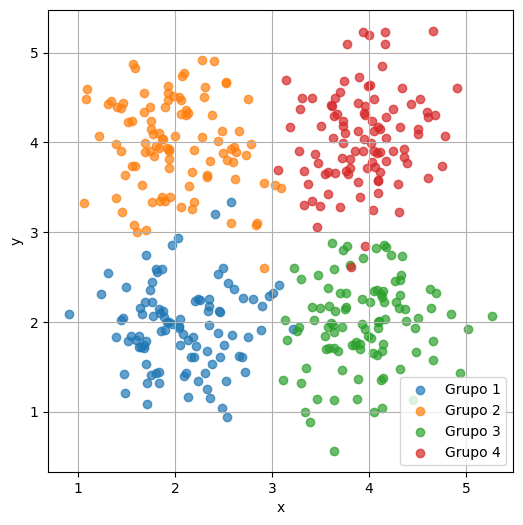

In [11]:
nc = 100
dimension = 2
std = 0.5

g1 = std*np.random.randn(nc, dimension) + np.array([2,2])
g2 = std*np.random.randn(nc, dimension) + np.array([2,4])
g3 = std*np.random.randn(nc, dimension) + np.array([4,2])
g4 = std*np.random.randn(nc, dimension) + np.array([4,4])

plt.figure(figsize=(6,6))
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
k1 = np.cov(g1.T)
k2 = np.cov(g2.T)
k3 = np.cov(g3.T)
k4 = np.cov(g4.T)

m1 = np.mean(g1, axis = 0)
m2 = np.mean(g2, axis = 0)
m3 = np.mean(g3, axis = 0)
m4 = np.mean(g4, axis = 0)


seqi = np.arange(0,6,0.1)
seqj = np.arange(0,6,0.1)

M = np.zeros(shape = (len(seqi),len(seqj)))

N1 = len(g1)
N2 = len(g2)
N3 = len(g3)
N4 = len(g4)

Nall = N1+N2+N3+N4

p1 = N1/Nall
p2 = N2/Nall
p3 = N3/Nall
p4 = N4/Nall

for ii, i in enumerate(seqi):       
    for jj, j in enumerate(seqj):  
        x = np.array([i, j])
        M[ii, jj] = (
            p1*pdf(x, m1, k1, dimension) +
            p2*pdf(x, m2, k2, dimension) +
            p3*pdf(x, m3, k3, dimension) +
            p4*pdf(x, m4, k4, dimension)
        )

/tmp/ipykernel_22741/4139100668.py:5: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



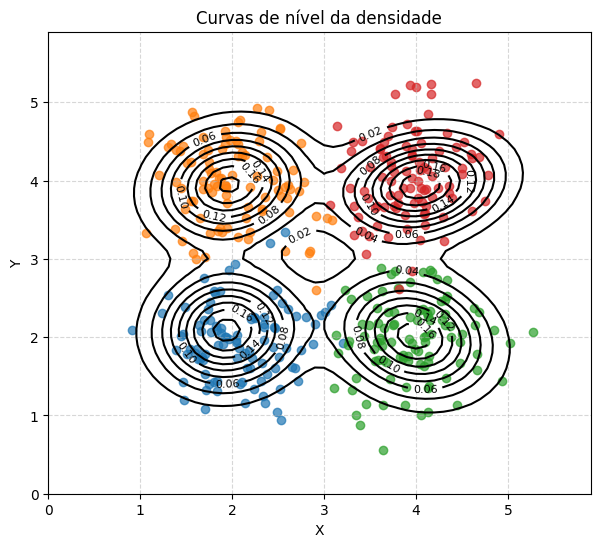

In [13]:
X, Y = np.meshgrid(seqi, seqj)
plt.figure(figsize=(7,6))
cs = plt.contour(X, Y, M, levels=10, colors="black")  
plt.clabel(cs, inline=True, fontsize=8) 
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)
plt.title("Curvas de nível da densidade")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [14]:
fig = go.Figure(data=[go.Surface(z=M, x=X, y=Y, colorscale="Viridis")])
fig.update_layout(
    title="Densidade da mistura Gaussiana",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Densidade"
    )
)
fig.show() 